In [31]:
import cv2
import dlib 
import IPython
import numpy as np
import pandas as pd 

In [4]:
def parse_vector(vector):
    return dlib.vector([float(x) for x in vector.split('\n')])

In [36]:
def show_image(cap, row):
    cap.set(cv2.CAP_PROP_POS_FRAMES, row['frame_num'])
    ret, frame = cap.read()
    _, ret = cv2.imencode('.jpg', frame)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)

In [3]:
src = '/home/amos/datasets/shining_bat_encodings.csv'
df = pd.read_csv(src, index_col=0)
df.head()

,x1,y1,x2,y2,right_eye_x,right_eye_y,left_eye_x,left_eye_y,nose_x,nose_y,...,face_num,img_width,img_height,filename,filepath,distance_from_center,pct_of_frame,encoding,series_id,episode_id
0,479,94,695,397,535,208,634,196,589,237,...,0,1280,720,shining_bat.mp4,/home/amos/programs/CineFace/data/test_videos/...,26.63,0.0708,-0.0674933\n0.0943281\n0.0449327\n0.00756572\n...,81505,15659200
1,515,114,730,422,570,231,669,223,623,276,...,0,1280,720,shining_bat.mp4,/home/amos/programs/CineFace/data/test_videos/...,27.04,0.0715,-0.0405336\n0.0716574\n0.0567907\n0.00282796\n...,81505,15659200
2,509,108,721,410,562,226,662,216,616,264,...,0,1280,720,shining_bat.mp4,/home/amos/programs/CineFace/data/test_videos/...,26.74,0.0695,-0.0331698\n0.0957054\n0.0514582\n0.0187592\n-...,81505,15659200
3,515,99,732,407,584,220,685,212,648,261,...,0,1280,720,shining_bat.mp4,/home/amos/programs/CineFace/data/test_videos/...,27.02,0.0722,-0.0560095\n0.0887332\n0.0417233\n0.0227062\n-...,81505,15659200
4,492,117,709,416,550,233,651,220,610,268,...,0,1280,720,shining_bat.mp4,/home/amos/programs/CineFace/data/test_videos/...,26.66,0.0698,-0.0416598\n0.103417\n0.0755524\n0.000812375\n...,81505,15659200


In [34]:
cap = cv2.VideoCapture(df.at[0, 'filepath'])

In [29]:
encodings = df['encoding'].map(parse_vector).tolist()
labels = dlib.chinese_whispers_clustering(encodings, 0.475)
df = df.assign(label=labels)
df.head()

,x1,y1,x2,y2,right_eye_x,right_eye_y,left_eye_x,left_eye_y,nose_x,nose_y,...,img_width,img_height,filename,filepath,distance_from_center,pct_of_frame,encoding,series_id,episode_id,label
0,479,94,695,397,535,208,634,196,589,237,...,1280,720,shining_bat.mp4,/home/amos/programs/CineFace/data/test_videos/...,26.63,0.0708,-0.0674933\n0.0943281\n0.0449327\n0.00756572\n...,81505,15659200,0
1,515,114,730,422,570,231,669,223,623,276,...,1280,720,shining_bat.mp4,/home/amos/programs/CineFace/data/test_videos/...,27.04,0.0715,-0.0405336\n0.0716574\n0.0567907\n0.00282796\n...,81505,15659200,0
2,509,108,721,410,562,226,662,216,616,264,...,1280,720,shining_bat.mp4,/home/amos/programs/CineFace/data/test_videos/...,26.74,0.0695,-0.0331698\n0.0957054\n0.0514582\n0.0187592\n-...,81505,15659200,0
3,515,99,732,407,584,220,685,212,648,261,...,1280,720,shining_bat.mp4,/home/amos/programs/CineFace/data/test_videos/...,27.02,0.0722,-0.0560095\n0.0887332\n0.0417233\n0.0227062\n-...,81505,15659200,0
4,492,117,709,416,550,233,651,220,610,268,...,1280,720,shining_bat.mp4,/home/amos/programs/CineFace/data/test_videos/...,26.66,0.0698,-0.0416598\n0.103417\n0.0755524\n0.000812375\n...,81505,15659200,0


In [30]:
df['label'].value_counts()

label
0    247
1     61
Name: count, dtype: int64

In [38]:
zero = df[df['label'] == 0]
one = df[df['label'] == 1]

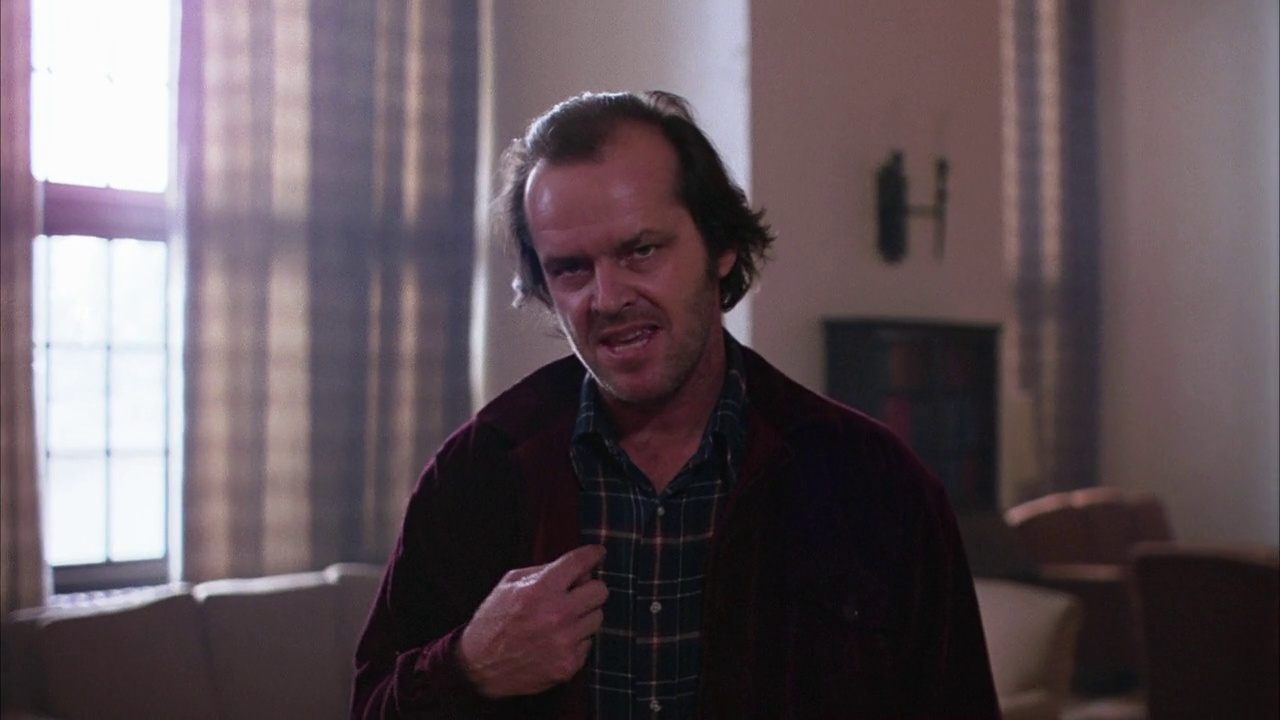

In [55]:
show_image(cap, one.iloc[41])